In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Retrieve training data

In [ ]:
import pandas as pd

train = pd.read_csv('train.csv')
display(train.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Label Encoding Categorical Features
Identify the categorical (object) columns and apply `LabelEncoder`.

In [ ]:
missing_data = train.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

In [ ]:
# col_types: dictionary of columns with missing data. Format {col_name: type}
col_types = {}
for val in train.columns:
  col_types[val] = train[val].dtype

In [ ]:
# Fill Missing Data
for col in col_types:
  if col_types[col] == 'object':
    train.fillna({col: "NaN"}, inplace=True)
  elif col_types[col] == 'int64' or col_types[col] == 'float64':
    train.fillna({col: -1}, inplace=True)
display(train.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_objects = train.select_dtypes(include=['object']).columns

# Apply label encoding to train data
for col in train_objects:
  train[col] = le.fit_transform(train[col])

print("Shape of train after Label Encoding:", train.shape)
display(train.head())

Shape of train after Label Encoding: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,1,3,3,0,...,0,3,4,1,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,1,3,3,0,...,0,3,4,1,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,1,0,3,0,...,0,3,4,1,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,1,0,3,0,...,0,3,4,1,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,1,0,3,0,...,0,3,4,1,0,12,2008,8,4,250000


### Normalization and Training model

In [ ]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

print(tf.__version__)

2.19.0


In [ ]:
# Split features/labels
train_features = train.copy()
train_labels = train_features.pop('SalePrice')

In [ ]:
# Generate normalizer
normalizer = tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(np.array(train_features))
print(normalizer.mean.numpy())

[[7.3050000e+02 5.6897259e+01 3.0287671e+00 5.7445889e+01 1.0516828e+04
  9.9589044e-01 9.9383563e-01 1.9424658e+00 2.7773972e+00 6.8493153e-04
  3.0191782e+00 6.2328767e-02 1.2251369e+01 2.0315068e+00 2.0082192e+00
  4.9315068e-01 3.0383561e+00 6.0993152e+00 5.5753427e+00 1.9712678e+03
  1.9848657e+03 1.4102740e+00 1.0753424e+00 9.6246576e+00 1.0339726e+01
  1.7623287e+00 1.0311164e+02 2.5397260e+00 3.7335618e+00 1.3965753e+00
  2.7246575e+00 3.6910958e+00 2.9369862e+00 3.1500001e+00 4.4363974e+02
  5.5869861e+00 4.6549316e+01 5.6724042e+02 1.0574294e+03 1.0363014e+00
  1.5383562e+00 9.3493152e-01 4.5958905e+00 1.1626267e+03 3.4699246e+02
  5.8445206e+00 1.5154637e+03 4.2534247e-01 5.7534248e-02 1.5650685e+00
  3.8287672e-01 2.8664384e+00 1.0465753e+00 2.3397260e+00 6.5178084e+00
  5.7493153e+00 6.1301368e-01 3.0876713e+00 2.4856164e+00 1.8686842e+03
  1.8767123e+00 1.7671233e+00 4.7298013e+02 4.7164383e+00 4.7630138e+00
  1.8561643e+00 9.4244522e+01 4.6660275e+01 2.1954109e+01 3.4095

In [ ]:
def build_and_compile_model(norm):
  model = keras.Sequential([
      norm,
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dense(1)
  ])

  model.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))
  return model

dnn_model = build_and_compile_model(normalizer)
dnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_3 (Normalization) │ (1460, 80)             │           161 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (648.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 161 (648.00 B)

In [ ]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('Error [SalePrice]')
  plt.legend()
  plt.grid(True)

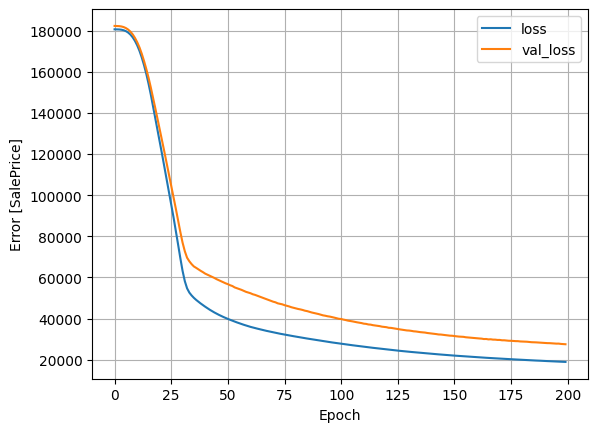

In [ ]:
history = dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0, epochs=200)
plot_loss(history)

### Retrieve and preprocess test data

In [ ]:
from sklearn.preprocessing import LabelEncoder

test = pd.read_csv('test.csv')

# Fill Missing Data
for col in col_types:
  if col_types[col] == 'object':
    test.fillna({col: "NaN"}, inplace=True)
  elif col_types[col] == 'int64' or col_types[col] == 'float64':
    test.fillna({col: -1}, inplace=True)

le = LabelEncoder()
test_objects = test.select_dtypes(include=['object']).columns

# Apply label encoding to test data
for col in test_objects:
  test[col] = le.fit_transform(test[col])

print("Shape of test after Label Encoding:", test.shape)
display(test.head())

Shape of test after Label Encoding: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,3,80.0,11622,1,1,3,3,0,...,120,0,2,2,1,0,6,2010,9,4
1,1462,20,4,81.0,14267,1,1,0,3,0,...,0,0,2,4,0,12500,6,2010,9,4
2,1463,60,4,74.0,13830,1,1,0,3,0,...,0,0,2,2,1,0,3,2010,9,4
3,1464,60,4,78.0,9978,1,1,0,3,0,...,0,0,2,4,1,0,6,2010,9,4
4,1465,120,4,43.0,5005,1,1,0,1,0,...,144,0,2,4,1,0,1,2010,9,4


### Make and export predictions

In [ ]:
predictions = dnn_model.predict(test).flatten()

submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": predictions
})

submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")
display(submission.head())

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Submission file 'submission.csv' created successfully.


,Id,SalePrice
0,1461,46823.054688
1,1462,49522.019531
2,1463,31839.935547
3,1464,38758.484375
4,1465,11199.002930
